# Software Engineering for Machine Learning Systems

Objective: Developing a model capable of predicting the precense of acute kidney injury for a dataset of patient blood test results.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("training.csv")
print(df.head())
print(f"No. of Patients: {df.shape[0]} No. of Features: {df.shape[1]}")

   age sex aki    creatinine_date_0  creatinine_result_0    creatinine_date_1  \
0   18   f   n  2024-01-01 07:54:00               102.56  2024-01-01 17:42:00   
1   58   m   n  2024-01-01 10:39:00               125.00  2024-01-02 06:47:00   
2   39   m   n  2024-01-01 14:26:00               187.44  2024-01-01 16:27:00   
3   27   f   n  2024-01-01 16:05:00               141.85  2024-01-19 13:57:00   
4    4   m   n  2024-01-01 16:17:00                72.29  2024-01-01 16:18:00   

   creatinine_result_1    creatinine_date_2  creatinine_result_2  \
0               108.55                  NaN                  NaN   
1               140.16  2024-01-02 07:10:00               145.98   
2               191.74  2024-01-09 10:46:00               197.47   
3               129.73  2024-09-21 05:57:00               132.16   
4                69.07  2024-01-05 10:54:00                72.91   

     creatinine_date_3  ...  creatinine_date_39 creatinine_result_39  \
0                  NaN  ...     

Supervised Binary Classification Problem

In [3]:
print(df['aki'].value_counts())
print(f"\nAKI percentages (%): {(df['aki'].value_counts(normalize=True) * 100).round(2)}")

aki
n    5785
y    1516
Name: count, dtype: int64

AKI percentages (%): aki
n    79.24
y    20.76
Name: proportion, dtype: float64


Some patients have creatinine measured early, after which testing stops. Which could be due to multiple reasons, for example: the patient was discharged, condition stabilised, a clinical decision was made, or the patient stopped coming for tests.

count    7301.000000
mean        8.242980
std         6.136986
min         1.000000
25%         4.000000
50%         7.000000
75%        11.000000
max        44.000000
Name: num_creatinine_tests, dtype: float64


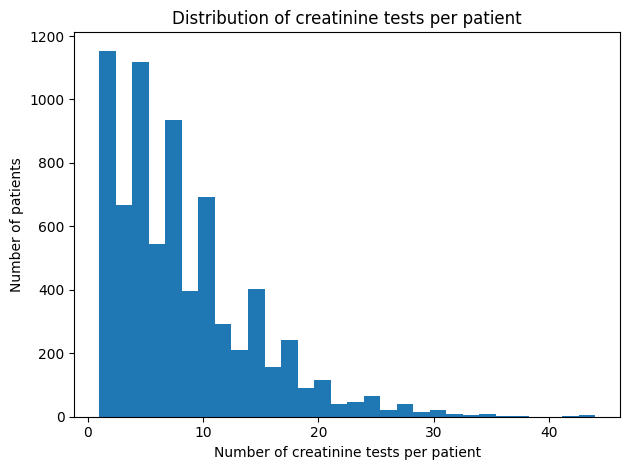

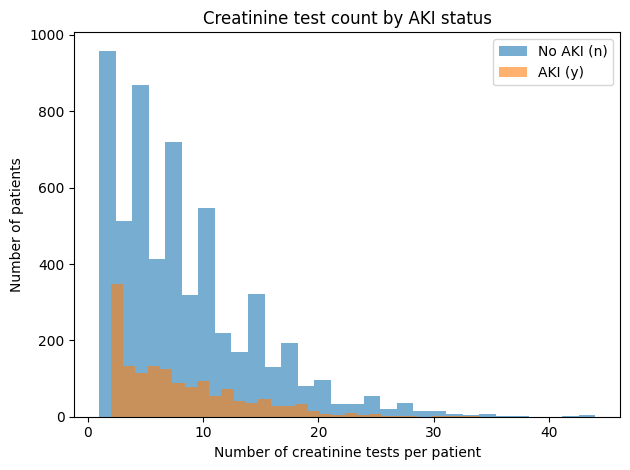

In [4]:
creat_cols = [c for c in df.columns if c.startswith("creatinine_result_")]
df["num_creatinine_tests"] = df[creat_cols].notna().sum(axis=1)
print(df["num_creatinine_tests"].describe())

plt.figure()
plt.hist(df["num_creatinine_tests"], bins=30)
plt.xlabel("Number of creatinine tests per patient")
plt.ylabel("Number of patients")
plt.title("Distribution of creatinine tests per patient")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(df.loc[df["aki"]=="n", "num_creatinine_tests"],
         bins=30, alpha=0.6, label="No AKI (n)")
plt.hist(df.loc[df["aki"]=="y", "num_creatinine_tests"],
         bins=30, alpha=0.6, label="AKI (y)")
plt.xlabel("Number of creatinine tests per patient")
plt.ylabel("Number of patients")
plt.title("Creatinine test count by AKI status")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/rf/cdrq8hf1343134rwldky___h0000gn/T/ipykernel_55852/2610797282.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


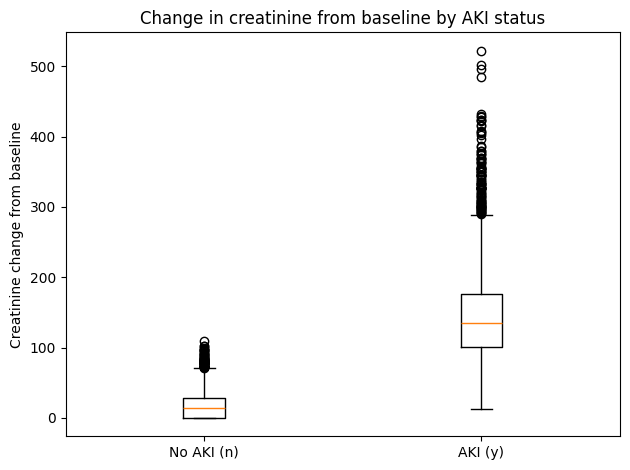

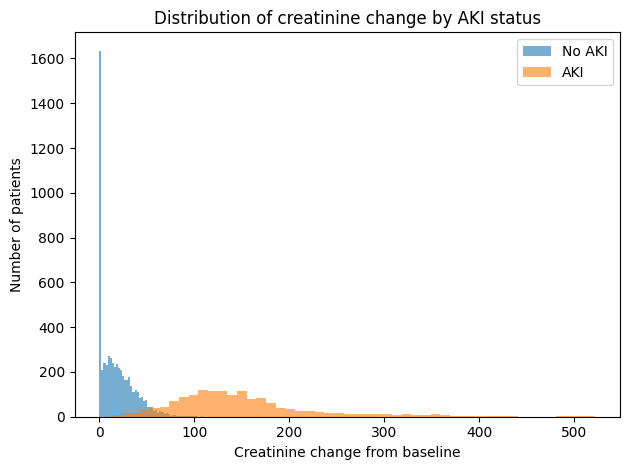

In [5]:
df["creatinine_baseline"] = df["creatinine_result_0"]
df["creatinine_peak"] = df[creat_cols].max(axis=1)
df["creatinine_change"] = df["creatinine_peak"] - df["creatinine_baseline"]

plt.figure()
plt.boxplot(
    [df.loc[df["aki"]=="n", "creatinine_change"].dropna(),
     df.loc[df["aki"]=="y", "creatinine_change"].dropna()],
    labels=["No AKI (n)", "AKI (y)"]
)
plt.ylabel("Creatinine change from baseline")
plt.title("Change in creatinine from baseline by AKI status")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(df.loc[df["aki"]=="n", "creatinine_change"], bins=50, alpha=0.6, label="No AKI")
plt.hist(df.loc[df["aki"]=="y", "creatinine_change"], bins=50, alpha=0.6, label="AKI")
plt.xlabel("Creatinine change from baseline")
plt.ylabel("Number of patients")
plt.title("Distribution of creatinine change by AKI status")
plt.legend()
plt.tight_layout()
plt.show()



sex
f    21.234222
m    20.315846
Name: aki, dtype: float64


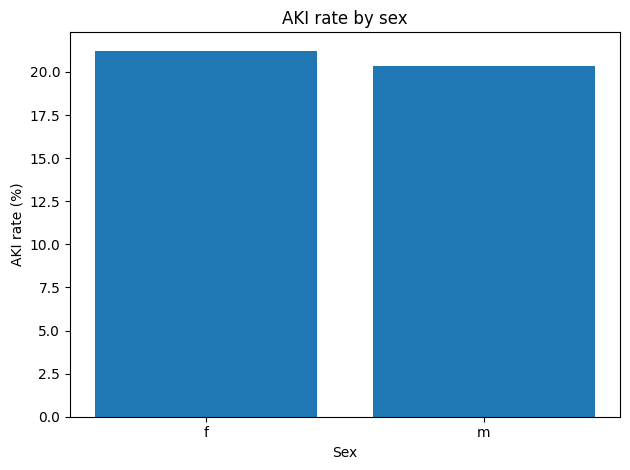

In [6]:
# AKI rate by sex
aki_by_sex = (
    df.groupby("sex")["aki"]
      .apply(lambda x: (x == "y").mean() * 100)
)

print(aki_by_sex)

# Bar plot
plt.figure()
plt.bar(aki_by_sex.index, aki_by_sex.values)
plt.ylabel("AKI rate (%)")
plt.xlabel("Sex")
plt.title("AKI rate by sex")
plt.tight_layout()
plt.show()


/var/folders/rf/cdrq8hf1343134rwldky___h0000gn/T/ipykernel_55852/2213308737.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_bin")["aki"]


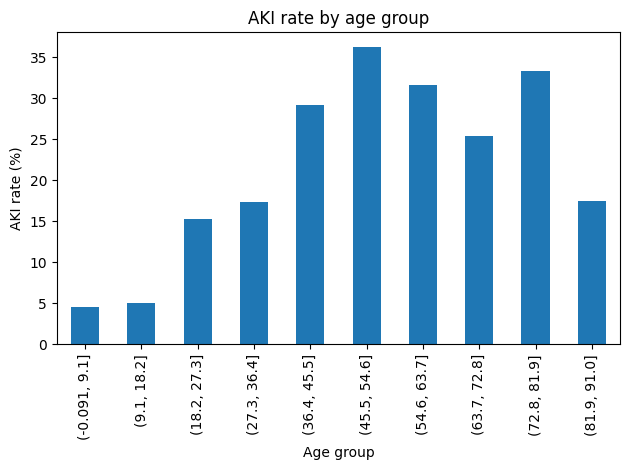

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df["age_bin"] = pd.cut(df["age"], bins=10)

aki_by_age = (
    df.groupby("age_bin")["aki"]
      .apply(lambda x: (x == "y").mean() * 100)
)

plt.figure()
aki_by_age.plot(kind="bar")
plt.ylabel("AKI rate (%)")
plt.xlabel("Age group")
plt.title("AKI rate by age group")
plt.tight_layout()
plt.show()


Conclusion from Data Analysis:
- Median number of tests per patient is around 7 (median used as its less affected by extreme values).
- Change in creatine is a good indicator of aki. (Shows seperability)
- aki rate by sex is relatively the same.
- aki incidence increases with age, particularly from middle age onwards, indicating higher risk in older populations.